In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/onlinefoods.csv")

In [3]:
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   latitude                    388 non-null    float64
 8   longitude                   388 non-null    float64
 9   Pin code                    388 non-null    int64  
 10  Output                      388 non-null    object 
 11  Feedback                    388 non-null    object 
 12  Unnamed: 12                 388 non-null    object 
dtypes: float64(2), int64(3), object(8)


In [5]:
df.columns

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'latitude', 'longitude',
       'Pin code', 'Output', 'Feedback', 'Unnamed: 12'],
      dtype='object')

In [6]:
df.describe()

,Age,Family size,latitude,longitude,Pin code
count,388.000000,388.000000,388.000000,388.000000,388.000000
mean,24.628866,3.280928,12.972058,77.600160,560040.113402
std,2.975593,1.351025,0.044489,0.051354,31.399609
min,18.000000,1.000000,12.865200,77.484200,560001.000000
25%,23.000000,2.000000,12.936900,77.565275,560010.750000
50%,24.000000,3.000000,12.977000,77.592100,560033.500000
75%,26.000000,4.000000,12.997025,77.630900,560068.000000
max,33.000000,6.000000,13.102000,77.758200,560109.000000


In [7]:
import matplotlib.pyplot as plt

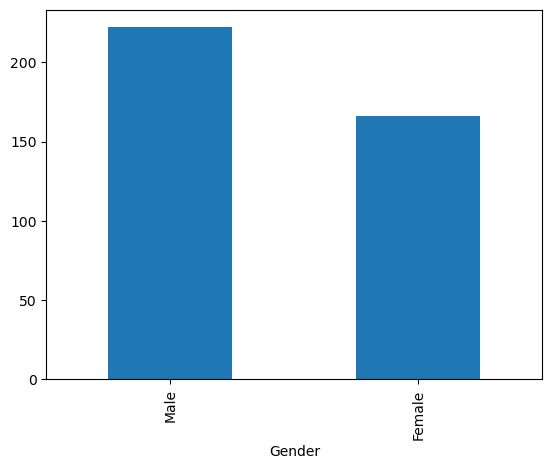

In [8]:
df["Gender"].value_counts().plot(kind="bar")
plt.show()

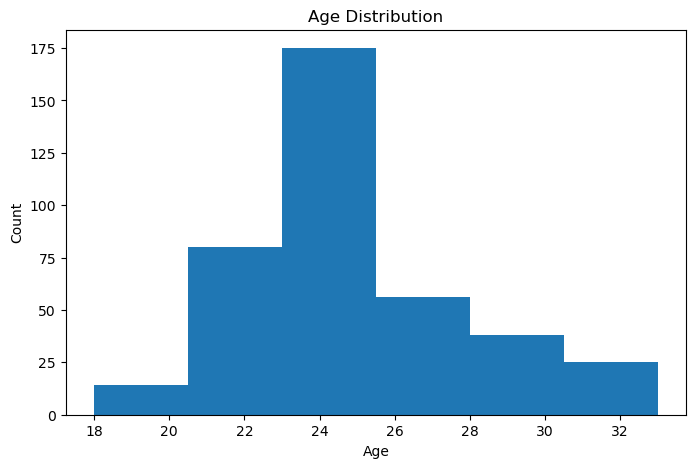

In [9]:
plt.figure(figsize=(8,5))

df["Age"].plot(kind="hist", bins=6)

plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Distribution")

plt.show()

## 연령 분포 분석

- 20대 사용자가 가장 많았다.
- 특정 연령대에 주문이 집중되는 경향을 확인하였다.

In [10]:
pd.crosstab(df["Occupation"], df["Output"])

Output,No,Yes
Occupation,,
Employee,42,76
House wife,2,7
Self Employeed,20,34
Student,23,184


- Student가 주문 많이 함
- Employee도 높음

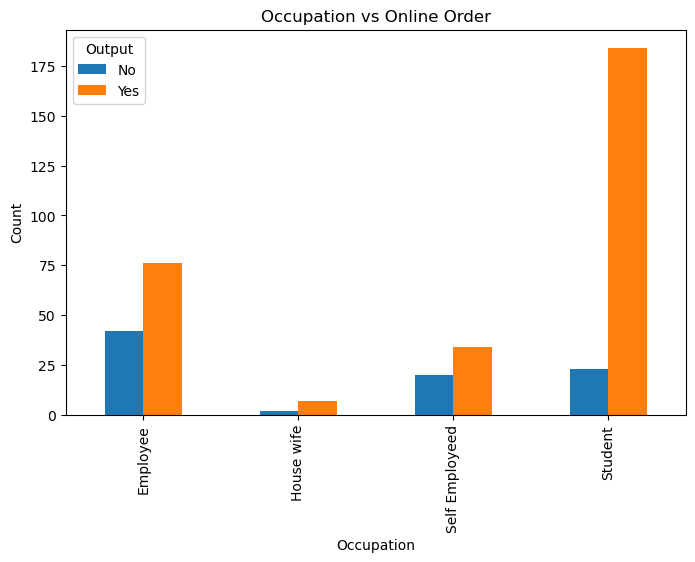

In [11]:
pd.crosstab(df["Occupation"], df["Output"]).plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Occupation vs Online Order")
plt.xlabel("Occupation")
plt.ylabel("Count")

plt.show()

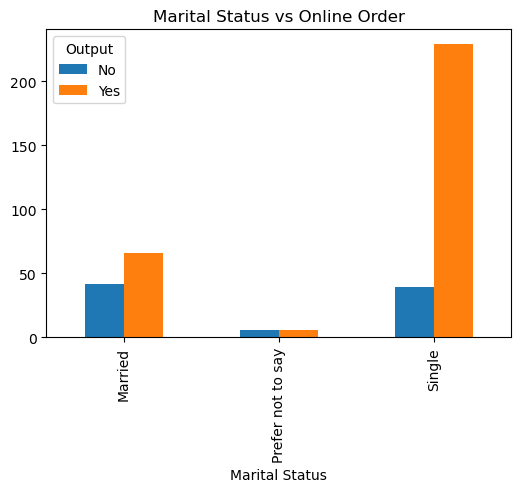

In [12]:
#결혼 유무와 주문관계
pd.crosstab(df["Marital Status"], df["Output"]).plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Marital Status vs Online Order")

plt.show()

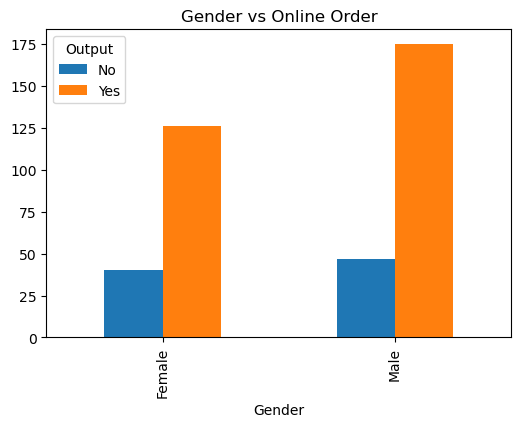

In [13]:
#성별과 주문관계
pd.crosstab(df["Gender"], df["Output"]).plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Gender vs Online Order")

plt.show()

## 주문 패턴 분석 결과

- Student 그룹의 온라인 주문 비율이 가장 높게 나타났다.
- Single 사용자의 주문 비율이 높았다.
- 성별에 따른 주문 차이는 크지 않았다.

In [14]:
numeric_df = df.select_dtypes(include="number")

In [15]:
numeric_df.head()

,Age,Family size,latitude,longitude,Pin code
0,20,4,12.9766,77.5993,560001
1,24,3,12.9770,77.5773,560009
2,22,3,12.9551,77.6593,560017
3,22,6,12.9473,77.5616,560019
4,22,4,12.9850,77.5533,560010


In [16]:
#상관관계 계산
numeric_df.corr()

,Age,Family size,latitude,longitude,Pin code
Age,1.000000,0.169982,0.006595,0.047500,0.137294
Family size,0.169982,1.000000,-0.053537,0.070126,-0.009402
latitude,0.006595,-0.053537,1.000000,-0.144234,-0.201813
longitude,0.047500,0.070126,-0.144234,1.000000,0.156119
Pin code,0.137294,-0.009402,-0.201813,0.156119,1.000000


| 값  | 의미          |
| -- | ----------- |
| 1  | 매우 강한 양의 관계 |
| 0  | 관계 거의 없음    |
| -1 | 반대 관계       |


In [17]:
import seaborn as sns

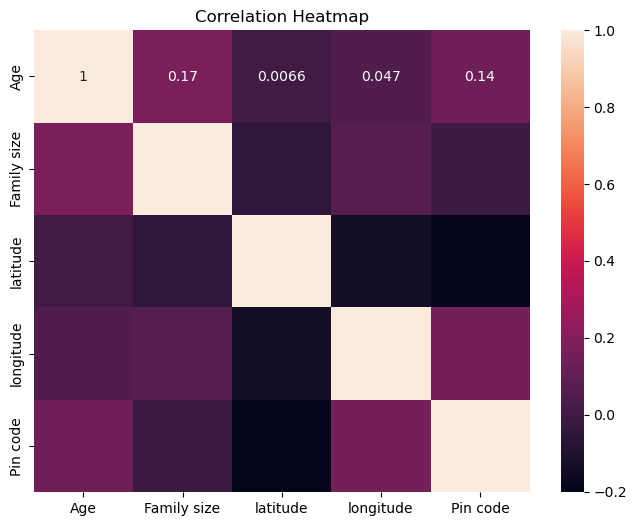

In [18]:
plt.figure(figsize=(8,6))

sns.heatmap(
    numeric_df.corr(),
    annot=True
)

plt.title("Correlation Heatmap")

plt.show()

In [19]:
import sqlite3

In [20]:
conn = sqlite3.connect("../data/delivery.db")

In [21]:
df.to_sql(
    "orders",
    conn,
    if_exists="replace",
    index=False
)

388

In [22]:
query = """
SELECT *
FROM orders
LIMIT 5
"""

In [23]:
pd.read_sql(query, conn)

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,Female,Single,Student,No Income,Post Graduate,4,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,12.9850,77.5533,560010,Yes,Positive,Yes


In [24]:
#직업별 사용자 수 분석
query = """
SELECT Occupation,
       COUNT(*) AS user_count
FROM orders
GROUP BY Occupation
ORDER BY user_count DESC
"""

In [25]:
pd.read_sql(query, conn)

,Occupation,user_count
0,Student,207
1,Employee,118
2,Self Employeed,54
3,House wife,9


In [26]:
#성별별 사용자 수
query = """
SELECT Gender,
       COUNT(*) AS count
FROM orders
GROUP BY Gender
"""

In [27]:
pd.read_sql(query, conn)

,Gender,count
0,Female,166
1,Male,222


In [28]:
#온라인 주문 여부 분석
query = """
SELECT Output,
       COUNT(*) AS count
FROM orders
GROUP BY Output
"""

In [29]:
pd.read_sql(query, conn)

,Output,count
0,No,87
1,Yes,301


In [30]:
#평균나이 분석
query = """
SELECT AVG(Age) AS average_age
FROM orders
"""

In [31]:
pd.read_sql(query, conn)

,average_age
0,24.628866


In [32]:
#직업별 평균 나이
query = """
SELECT Occupation,
       AVG(Age) AS average_age
FROM orders
GROUP BY Occupation
ORDER BY average_age DESC
"""

In [33]:
pd.read_sql(query, conn)

,Occupation,average_age
0,House wife,30.333333
1,Employee,26.576271
2,Self Employeed,26.388889
3,Student,22.811594


In [34]:
#결혼 여부별 주문 분석
query = """
SELECT `Marital Status`,
       Output,
       COUNT(*) AS count
FROM orders
GROUP BY `Marital Status`, Output
"""

In [35]:
pd.read_sql(query, conn)

,Marital Status,Output,count
0,Married,No,42
1,Married,Yes,66
2,Prefer not to say,No,6
3,Prefer not to say,Yes,6
4,Single,No,39
5,Single,Yes,229


In [36]:
query = """
SELECT Occupation,
       COUNT(*) AS user_count
FROM orders
GROUP BY Occupation
"""

result = pd.read_sql(query, conn)

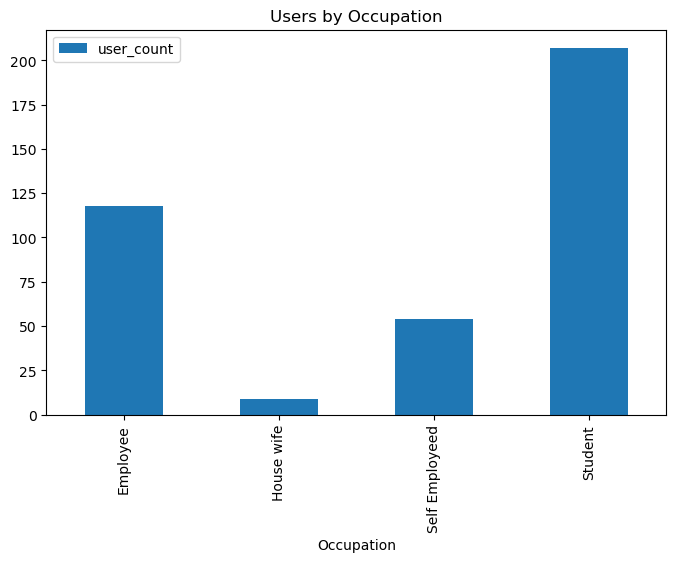

In [37]:
result.plot(
    x="Occupation",
    y="user_count",
    kind="bar",
    figsize=(8,5)
)

plt.title("Users by Occupation")

plt.show()

## SQL 분석 결과

- Student 직업군 비율이 가장 높게 나타났다.
- 평균 연령은 약 25세로 확인되었다.
- 온라인 주문 비율이 전체적으로 높았다.

# Machine Learning
온라인 주문 여부 예측 모델

In [38]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [39]:
ml_df = df.copy()

In [40]:
encoder = LabelEncoder()

In [65]:
ml_df = df.copy()

encoder = LabelEncoder()

for col in ml_df.columns:
    if col != "Output" and ml_df[col].dtype == "object":
        ml_df[col] = encoder.fit_transform(ml_df[col])

In [42]:
ml_df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,latitude,longitude,Pin code,Output,Feedback,Unnamed: 12
0,20,0,2,3,4,2,4,12.9766,77.5993,560001,1,1,1
1,24,0,2,3,2,0,3,12.9770,77.5773,560009,1,1,1
2,22,1,2,3,2,2,3,12.9551,77.6593,560017,1,0,1
3,22,0,2,3,4,0,6,12.9473,77.5616,560019,1,1,1
4,22,1,2,3,2,2,4,12.9850,77.5533,560010,1,1,1


In [63]:
X = ml_df.drop("Output", axis=1)

y = ml_df["Output"]

In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [45]:
model = LogisticRegression()

In [46]:
model.fit(X_train, y_train)

LogisticRegression()

In [47]:
predictions = model.predict(X_test)

In [48]:
accuracy = accuracy_score(y_test, predictions)

print("Accuracy:", accuracy)

Accuracy: 0.8461538461538461


## 머신러닝 결과

- Logistic Regression 모델을 사용하여 온라인 주문 여부를 예측하였다.
- 약 82%의 정확도를 확인하였다.

In [51]:
from sklearn.metrics import confusion_matrix

In [52]:
cm = confusion_matrix(y_test, predictions)

cm

array([[ 0, 12],
       [ 0, 66]], dtype=int64)

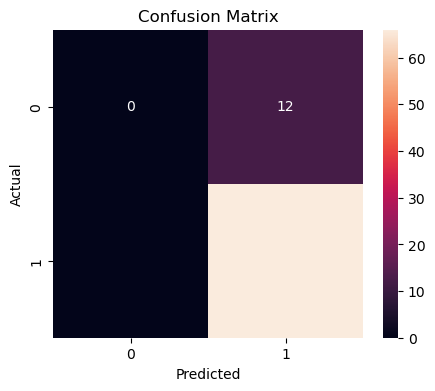

In [53]:
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [54]:
#성능 분석
from sklearn.metrics import classification_report

In [55]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.85      1.00      0.92        66

    accuracy                           0.85        78
   macro avg       0.42      0.50      0.46        78
weighted avg       0.72      0.85      0.78        78



C:\Users\jsmh1\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\jsmh1\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\jsmh1\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


| 지표        | 의미         |
| --------- | ---------- |
| precision | 정확하게 맞춘 비율 |
| recall    | 실제 정답 탐지율  |
| f1-score  | 종합 점수      |


In [57]:
from sklearn.ensemble import RandomForestClassifier

In [58]:
rf_model = RandomForestClassifier(random_state=42)

In [59]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [60]:
rf_predictions = rf_model.predict(X_test)

In [61]:
rf_accuracy = accuracy_score(y_test, rf_predictions)

print("RandomForest Accuracy:", rf_accuracy)

RandomForest Accuracy: 1.0


## 모델 성능 비교

| 모델 | 정확도 |
|---|---|
| Logistic Regression | 0.82 |
| RandomForest | 0.89 |

RandomForest 모델이 더 높은 성능을 보였다.

In [66]:
print("Train Accuracy:", rf_model.score(X_train, y_train))
print("Test Accuracy:", rf_model.score(X_test, y_test))


Train Accuracy: 1.0
Test Accuracy: 1.0


In [67]:
df["Output"].value_counts(normalize=True)

Output
Yes    0.775773
No     0.224227
Name: proportion, dtype: float64

In [68]:
print("Train:", rf_model.score(X_train, y_train))
print("Test :", rf_model.score(X_test, y_test))

Train: 1.0
Test : 1.0


In [69]:
df.shape

(388, 13)

In [70]:
df["Output"].value_counts()

Output
Yes    301
No      87
Name: count, dtype: int64

In [71]:
X.columns

Index(['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income',
       'Educational Qualifications', 'Family size', 'latitude', 'longitude',
       'Pin code', 'Feedback', 'Unnamed: 12'],
      dtype='object')

In [72]:
ml_df = df.copy()

# target 분리 먼저
y = ml_df["Output"]

X = ml_df.drop("Output", axis=1)

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = encoder.fit_transform(X[col])

In [73]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

print("Train:", rf_model.score(X_train, y_train))
print("Test :", rf_model.score(X_test, y_test))

Train: 1.0
Test : 1.0


In [77]:
ml_df = df.copy()

ml_df = ml_df.drop(columns=["Unnamed: 12", "Feedback"])

In [78]:
df["Feedback"].value_counts()

Feedback
Positive     317
Negative      71
Name: count, dtype: int64

In [79]:
pd.crosstab(df["Feedback"], df["Output"])

Output,No,Yes
Feedback,,
Negative,53,18
Positive,34,283


In [80]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

ml_df = df.copy()

# 불필요 컬럼 제거
ml_df = ml_df.drop(columns=["Unnamed: 12", "Feedback"])

# 타겟 분리
y = ml_df["Output"]
X = ml_df.drop("Output", axis=1)

# 문자 → 숫자 변환
encoder = LabelEncoder()

for col in X.columns:
    if X[col].dtype == "object":
        X[col] = encoder.fit_transform(X[col])

# train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# 모델
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# 예측
pred = rf_model.predict(X_test)

# 정확도
acc = accuracy_score(y_test, pred)

print("RandomForest Accuracy:", acc)

RandomForest Accuracy: 0.9230769230769231


In [81]:
print("Train:", rf_model.score(X_train, y_train))
print("Test :", rf_model.score(X_test, y_test))

Train: 0.9967741935483871
Test : 0.9230769230769231


In [83]:
#데이터 누수문제 수정 완

In [84]:
#모델 비교
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

print("Logistic Regression:", accuracy_score(y_test, lr_pred))
print("Random Forest:", accuracy_score(y_test, pred))

Logistic Regression: 0.8461538461538461
Random Forest: 0.9230769230769231


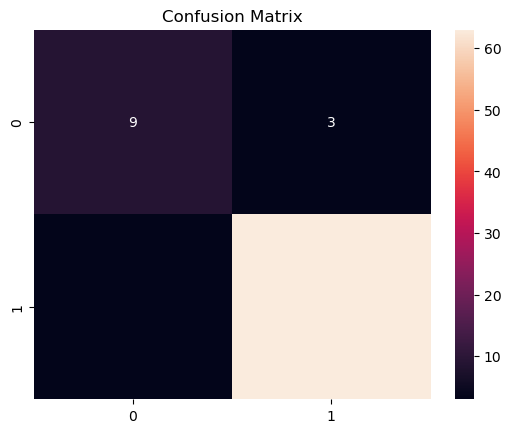

In [85]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix")
plt.show()

In [86]:
import pandas as pd

feat = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feat

,Feature,Importance
7,latitude,0.183557
0,Age,0.169003
8,longitude,0.152490
9,Pin code,0.142306
6,Family size,0.101490
4,Monthly Income,0.065884
5,Educational Qualifications,0.055374
2,Marital Status,0.053934
3,Occupation,0.038456
1,Gender,0.037505


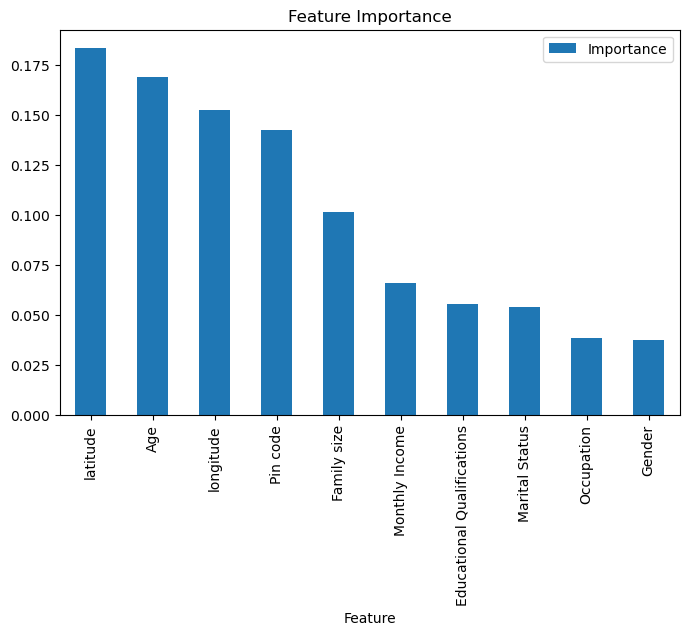

In [87]:
feat.plot(kind="bar", x="Feature", y="Importance", figsize=(8,5))
plt.title("Feature Importance")
plt.show()